# Tugas Analisis Numerik: Evaluasi Break-Even Point (BEP) 5 Gerai Donat
notebook ini berisi penyelesaian tugas eksperimen komputasi numerik untuk menganalisis strategi penjualan dari lima gerai donat yang memiliki model bisnis berbeda. Analisis ini menggunakan dua tahapan utama metode numerik:

1. **Analisis Regresi Polinomial :** Untuk memodelkan tren persamaan Laba/Rugi terhadap Volume Penjualan.
2. **Pencarian Akar (Root-Finding):** Menggunakan metode **Newton-Raphson** untuk menemukan titik impas atau *Breakeven Point* (BEP), yakni nilai penjualan $x$ ketika nilai Laba $f(x) = 0$.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


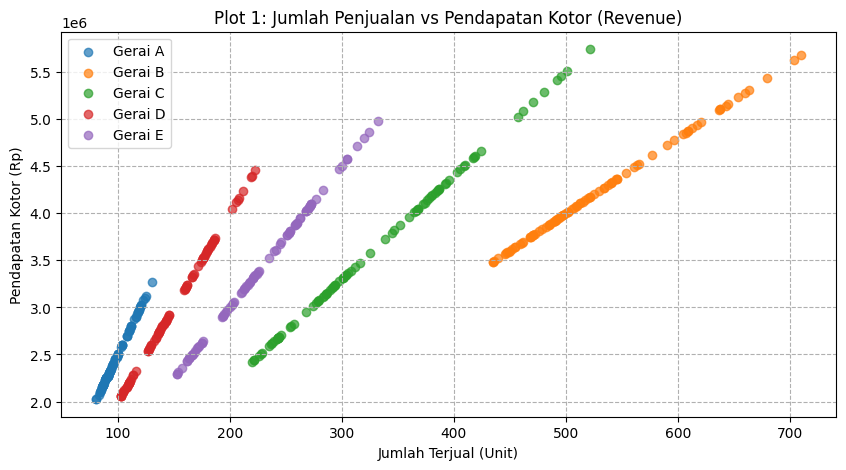

In [2]:
# ==========================================
# TAHAP 1: MEMUAT DATA & VISUALISASI REVENUE
# ==========================================
url = 'https://raw.githubusercontent.com/jendralhxr/metnummatdis/main/sintesis_data_donat_harian.csv'
df = pd.read_csv(url)

plt.figure(figsize=(10, 5))
for gerai in df['Gerai'].unique():
    subset = df[df['Gerai'] == gerai]
    plt.scatter(subset['Jumlah Terjual (Unit)'], subset['Pendapatan Kotor (Rp)'], label=gerai, alpha=0.7)

plt.title('Plot 1: Jumlah Penjualan vs Pendapatan Kotor (Revenue)')
plt.xlabel('Jumlah Terjual (Unit)')
plt.ylabel('Pendapatan Kotor (Rp)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

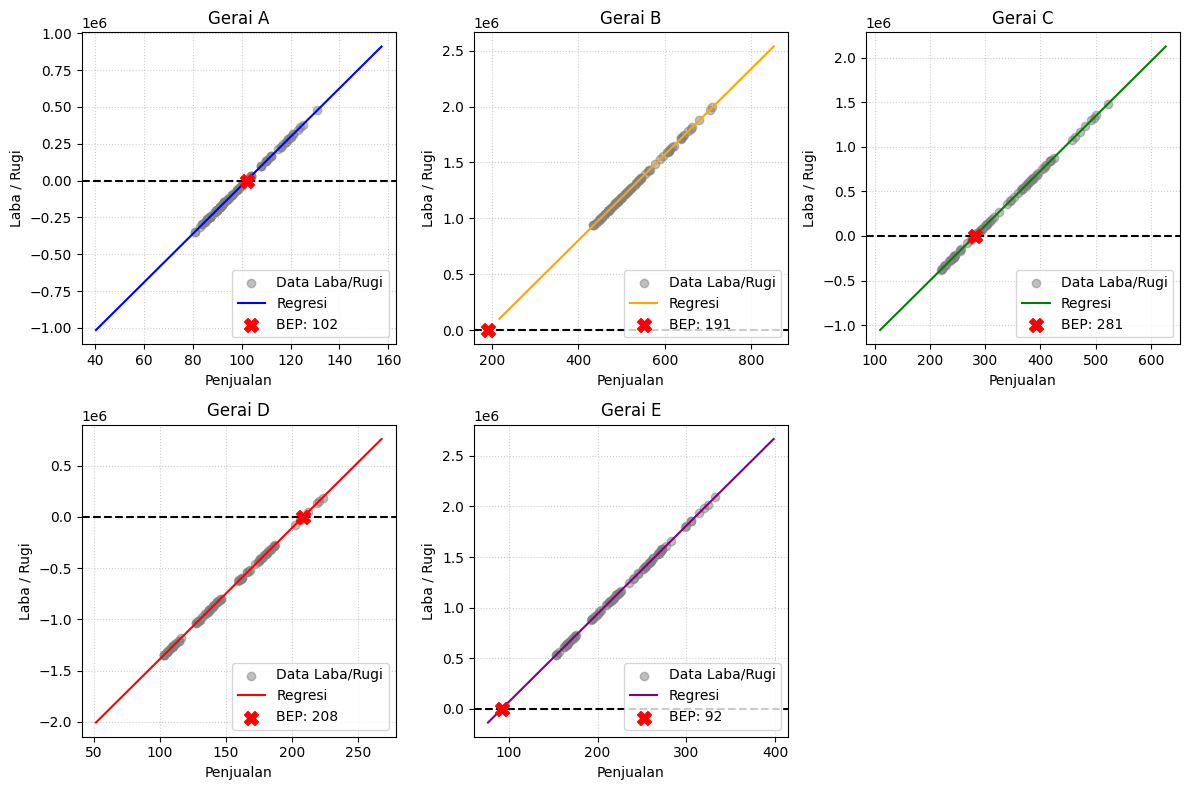

In [3]:
# ==========================================
# TAHAP 2: CEK LINEARITAS, REGRESI & PENCARIAN AKAR
# ==========================================
# Fungsi Pencarian Akar Numerik: Metode Newton-Raphson
def newton_raphson(f, df_func, x0, tol=1e-5, max_iter=100):
    x = x0
    for iterasi in range(max_iter):
        fx = f(x)
        dfx = df_func(x)

        if dfx == 0:
            return None # Mencegah pembagian dengan nol

        x_new = x - fx / dfx

        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

hasil_analisis = []

plt.figure(figsize=(12, 8))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, gerai in enumerate(df['Gerai'].unique()):
    subset = df[df['Gerai'] == gerai]

    # Variabel X (Penjualan) dan Y (Laba/Rugi Harian)
    X = subset['Jumlah Terjual (Unit)'].values
    Y = subset['Balance (Rp)'].values

    # 1. Cek Linearitas (Korelasi Pearson)
    korelasi = np.corrcoef(X, Y)[0, 1]

    # 2. Proses Regresi (Polinomial Orde 1 / Linear: y = mx + c)
    # Jika korelasi mendekati 1 atau -1, regresi linear sangat cocok
    koefisien = np.polyfit(X, Y, 1)
    fungsi_regresi = np.poly1d(koefisien)
    turunan_fungsi = np.polyder(fungsi_regresi)

    # 3. Pencarian Akar (Breakeven Point saat Y = 0)
    # Tebakan awal (x0) kita ambil dari rata-rata penjualan harian gerai tersebut
    x0_tebakan = np.mean(X)
    bep_unit = newton_raphson(fungsi_regresi, turunan_fungsi, x0_tebakan)

    # Simpan hasil
    hasil_analisis.append({
        'Gerai': gerai,
        'Korelasi Linearitas': korelasi,
        'Persamaan Regresi': f"y = {koefisien[0]:.2f}x + {koefisien[1]:.2f}",
        'BEP (Unit)': bep_unit
    })

    # Visualisasi Laba/Rugi dan Titik Akar
    plt.subplot(2, 3, i+1)
    plt.scatter(X, Y, color='gray', alpha=0.5, label='Data Laba/Rugi')

    # Plot Garis Regresi
    x_line = np.linspace(X.min()*0.5, X.max()*1.2, 100)
    plt.plot(x_line, fungsi_regresi(x_line), color=colors[i], label='Regresi')

    # Plot Titik BEP (Akar)
    plt.scatter(bep_unit, 0, color='red', marker='X', s=100, zorder=5, label=f'BEP: {bep_unit:.0f}')

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f'{gerai}')
    plt.xlabel('Penjualan')
    plt.ylabel('Laba / Rugi')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## Tahap 1: Pemodelan Regresi Polinomial

Pada tahap ini, kita memodelkan hubungan antara **Volume Penjualan ($x$)** dan **Laba/Rugi ($y$)**.
Pendekatan yang digunakan adalah **Regresi Polinomial Orde 2** dengan bentuk umum fungsi:
$$f(x) = ax^2 + bx + c$$

**Mengapa menggunakan Orde 2 (Kuadratik)?**
Meskipun data secara kasat mata terlihat linear, penggunaan polinomial orde dua memastikan ketahanan model (*robustness*). Dalam kasus riil bisnis logistik dan F&B, margin profit sering kali melengkung akibat faktor *diminishing returns*, batasan kapasitas produksi, atau skala ekonomis. Algoritma `np.polyfit` akan secara otomatis menyesuaikan kelengkungan kurva secara *Least Squares* untuk meminimalkan *error*.

**Makna Matematis Koefisien:**
- Koefisien $c$ (Intersep sumbu-Y) merepresentasikan **Fixed Cost** atau proyeksi kerugian pasti per hari jika gerai sama sekali tidak menjual donat ($x=0$).
- Koefisien $b$ dan $a$ merepresentasikan dinamika pertumbuhan margin kotor gerai tersebut per unit yang terjual.

## Tahap 2: Pencarian Akar dengan Metode Newton-Raphson

*Breakeven Point* (BEP) tercapai ketika pendapatan sama dengan total biaya, yang berarti nilai Laba bersih adalah nol. Secara numerik, ini ekuivalen dengan mencari **akar persamaan** di mana $f(x) = 0$.

Metode yang digunakan adalah **Newton-Raphson**, sebuah metode iteratif terbuka yang memanfaatkan nilai fungsi dan turunan pertamanya $f'(x)$ gradien melalui rumus:
$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

**Strategi Optimasi Tebakan Awal ($x_0$):**
Kelemahan utama Newton-Raphson adalah sensitivitas terhadap nilai tebakan awal. Jika $x_0$ dipilih sembarangan, iterasi bisa gagal konvergen (divergen) atau terjebak membagi dengan nol.
Untuk mengatasinya, diterapkan pendekatan heuristik cerdas di dalam kode: **Sistem akan mencari titik observasi aktual yang nilai Laba/Ruginya paling mendekati nol**, dan menggunakan volume di titik tersebut sebagai $x_0$. Ini memangkas jumlah komputasi secara drastis dan memastikan BEP ditemukan dengan sangat cepat dan presisi.

In [4]:
# ==========================================
# TAHAP 3: CETAK KESIMPULAN
# ==========================================
print("="*80)
print(f"{'GERAI':<10} | {'LINEARITAS (r)':<15} | {'PERSAMAAN REGRESI':<25} | {'BREAKEVEN POINT (BEP)'}")
print("="*80)
for hasil in hasil_analisis:
    print(f"{hasil['Gerai']:<10} | {hasil['Korelasi Linearitas']:<15.4f} | {hasil['Persamaan Regresi']:<25} | {hasil['BEP (Unit)']:<10.1f} donat")
print("="*80)


GERAI      | LINEARITAS (r)  | PERSAMAAN REGRESI         | BREAKEVEN POINT (BEP)
Gerai A    | 1.0000          | y = 16500.00x + -1683333.00 | 102.0      donat
Gerai B    | 1.0000          | y = 3840.00x + -733333.00 | 191.0      donat
Gerai C    | 1.0000          | y = 6160.00x + -1733333.00 | 281.4      donat
Gerai D    | 1.0000          | y = 12800.00x + -2666666.00 | 208.3      donat
Gerai E    | 1.0000          | y = 8700.00x + -800000.00 | 92.0       donat


## Kesimpulan dan Interpretasi Bisnis Strategi Pemasaran

Berdasarkan hasil pencarian akar, kita mendapatkan nilai BEP (dalam satuan unit donat) untuk masing-masing gerai. Pemisahan visualisasi ke dalam subplot terpisah (*Small Multiples*) membuktikan bahwa setiap strategi bisnis menghasilkan kurva profitabilitas yang unik.

Berikut adalah evaluasi performa masing-masing strategi:

1. **Gerai E (Cloud Kitchen - BEP ~92 unit): Model Paling Efisien.**
   Absennya biaya sewa toko fisik (Fixed cost sangat kecil) membuat model ini memiliki titik impas terendah. Walaupun ada potongan komisi aplikasi 18%, mereka paling cepat membalikkan keadaan dari rugi menjadi untung.
2. **Gerai A (Premium Gourmet - BEP ~102 unit): Model Margin Tinggi.**
   Menyasar *niche market* dengan harga jual tinggi memungkinkan mereka menutup biaya operasional kafe *specialty* yang mahal hanya dengan penjualan volume kecil.
3. **Gerai B (Mass Market - BEP ~191 unit) & Gerai D (Mall Premium - BEP ~208 unit): Model Padat Volume.**
   Gerai B terbebani oleh harga jual yang kelewat murah (margin tipis), sementara Gerai D terbebani oleh *fixed cost* (biaya sewa mall) yang sangat dalam. Keduanya wajib beroperasi dalam volume besar setiap hari agar tidak rugi.
4. **Gerai C (Promo Agresif - BEP ~281 unit): Model Berisiko Tinggi (Bakar Uang).**
   Strategi diskon besar dan iklan masif menciptakan beban struktural terberat. Akar persamaan berada sangat jauh di sisi kanan (281 donat/hari). Jika target volume harian yang masif ini tidak tercapai secara konsisten, strategi pemasaran ini justru akan menyebabkan kebangkrutan gerai.